# Market Signal Analysis - Volatile Sample

This notebook performs a simple market time-series analysis using sample price data.

The goal is to demonstrate basic data loading, timestamp cleaning, feature engineering, and visual inspection of price and volatility.


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys

sys.path.append(str(Path.cwd().parent / "src"))

from metrics import (
    calculate_returns,
    calculate_max_drawdown,
    calculate_win_rate,
    calculate_sharpe_like,
)
from signals import momentum_signal

dataset_file = "volatile_sample_prices.csv"
data_path = Path("../data") / dataset_file

print(f"Using dataset: {dataset_file}")

df = pd.read_csv(data_path)

df.head()

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.head()

df.info()


Using dataset: volatile_sample_prices.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 72 entries, 2024-01-01 00:00:00 to 2024-01-03 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   72 non-null     float64
dtypes: float64(1)
memory usage: 1.1 KB


## Feature engineering


In [3]:
rolling_window = 24

df["return"] = calculate_returns(df["close"])
df["rolling_mean"] = df["close"].rolling(window=rolling_window).mean()
df["rolling_volatility"] = df["return"].rolling(window=rolling_window).std()

df.head(30)

,close,return,rolling_mean,rolling_volatility
timestamp,,,,
2024-01-01 00:00:00,101.1643,NaN,NaN,NaN
2024-01-01 01:00:00,101.0332,-0.001296,NaN,NaN
2024-01-01 02:00:00,101.2047,0.001697,NaN,NaN
2024-01-01 03:00:00,101.6040,0.003945,NaN,NaN
2024-01-01 04:00:00,101.2754,-0.003234,NaN,NaN
2024-01-01 05:00:00,101.4286,0.001513,NaN,NaN
2024-01-01 06:00:00,101.5802,0.001495,NaN,NaN
2024-01-01 07:00:00,100.6631,-0.009028,NaN,NaN
2024-01-01 08:00:00,101.4287,0.007606,NaN,NaN


# Price chart


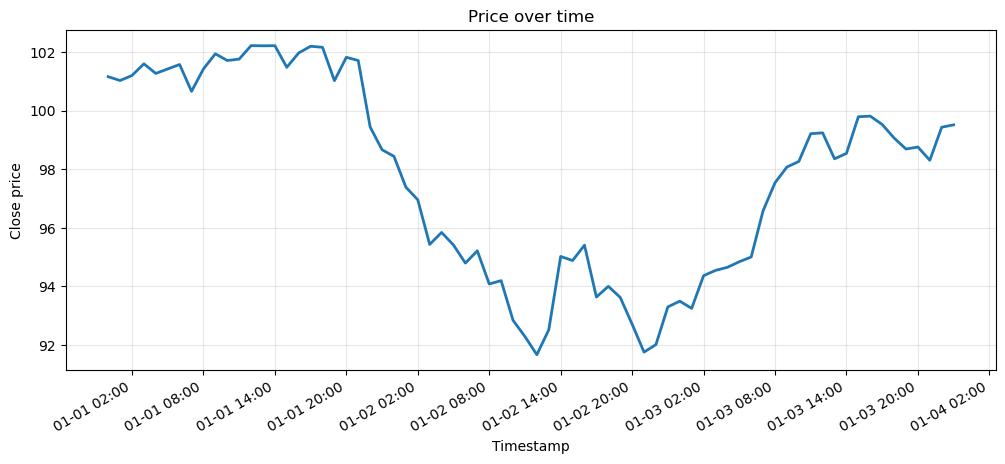

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["close"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Price over time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Close price")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


# Rolling volatility chart

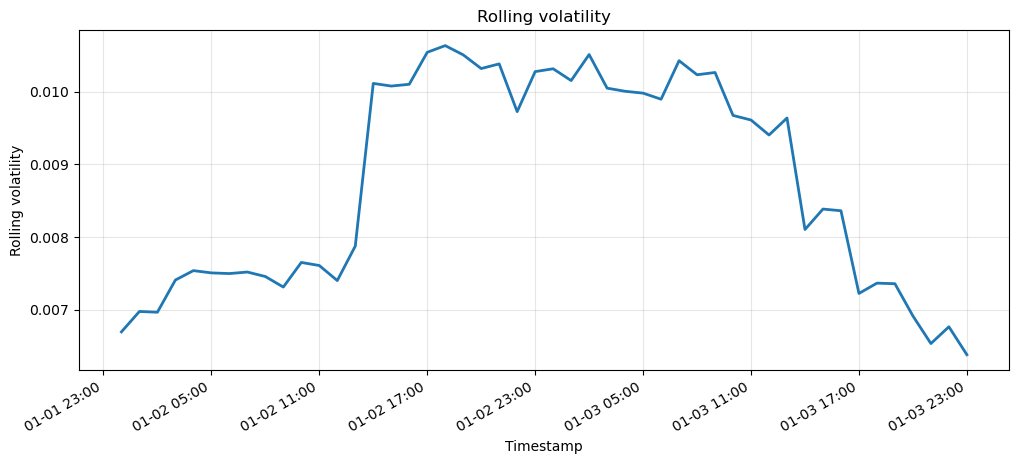

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["rolling_volatility"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Rolling volatility")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rolling volatility")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Initial observations

The dataset is sorted by timestamp and indexed as a time series.  
The return column measures percentage price changes between consecutive observations.  
Rolling volatility is calculated as the rolling standard deviation of returns.

At this stage, the notebook only performs basic exploratory analysis. No trading signal or backtest is included yet.


## Momentum signal

A simple momentum signal is based on recent returns.  
If the rolling return is positive, the signal is long. If it is negative, the signal is short.


In [6]:
signal_window = 12

df["momentum_signal"] = momentum_signal(df["return"], window=signal_window)

df[["return", "momentum_signal"]].tail()


,return,momentum_signal
timestamp,,
2024-01-03 19:00:00,-0.003800,1
2024-01-03 20:00:00,0.000699,1
2024-01-03 21:00:00,-0.004580,1
2024-01-03 22:00:00,0.011486,1
2024-01-03 23:00:00,0.000804,1


## Backtest setup

The signal is shifted by one period before calculating momentum returns.  
This avoids using information from the current bar to trade the same bar.


In [7]:
df["momentum_position"] = df["momentum_signal"].shift(1)

df[["momentum_signal", "momentum_position"]].tail()


,momentum_signal,position
timestamp,,
2024-01-03 19:00:00,1,1.0
2024-01-03 20:00:00,1,1.0
2024-01-03 21:00:00,1,1.0
2024-01-03 22:00:00,1,1.0
2024-01-03 23:00:00,1,1.0


## Momentum returns

Momentum returns are calculated by multiplying the shifted position by the market return.


In [8]:
df["momentum_return"] = df["momentum_position"] * df["return"]
df["momentum_equity_curve"] = (1 + df["momentum_return"].fillna(0)).cumprod()

df[["return", "momentum_position", "momentum_return", "momentum_equity_curve"]].tail()


,return,position,strategy_return,equity_curve
timestamp,,,,
2024-01-03 19:00:00,-0.003800,1.0,-0.003800,1.121570
2024-01-03 20:00:00,0.000699,1.0,0.000699,1.122354
2024-01-03 21:00:00,-0.004580,1.0,-0.004580,1.117214
2024-01-03 22:00:00,0.011486,1.0,0.011486,1.130046
2024-01-03 23:00:00,0.000804,1.0,0.000804,1.130954


## Momentum metrics

The metrics summarize the simplified momentum backtest.


In [9]:
metrics = {
    "cumulative_return": df["momentum_equity_curve"].iloc[-1] - 1,
    "max_drawdown": calculate_max_drawdown(df["momentum_equity_curve"]),
    "win_rate": calculate_win_rate(df["momentum_return"]),
    "sharpe_like": calculate_sharpe_like(
        df["momentum_return"],
        periods_per_year=24 * 365,
    ),
}

metrics


{'cumulative_return': 0.1309542238144359,
 'max_drawdown': -0.04004635344896046,
 'win_rate': 0.49295774647887325,
 'sharpe_like': 21.144415632655214}

## Momentum equity curve


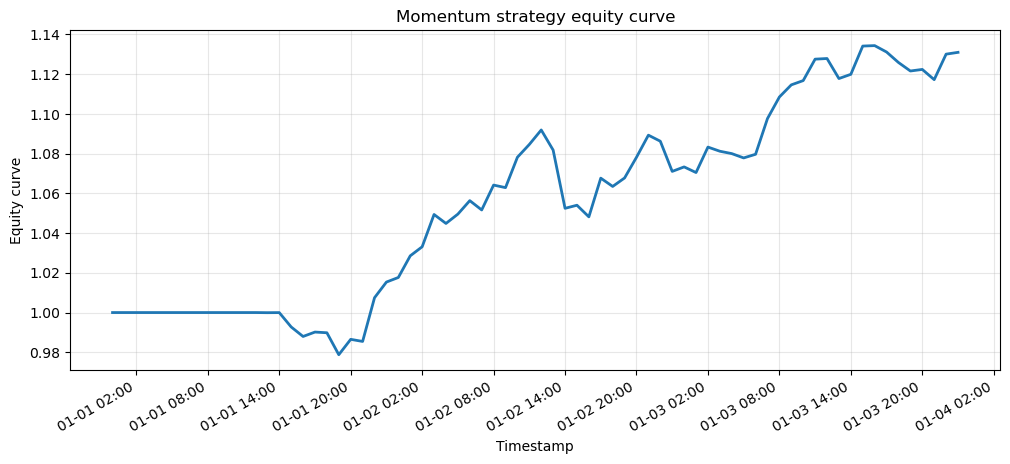

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["momentum_equity_curve"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Momentum strategy equity curve")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Equity curve")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Backtest interpretation

The momentum signal produces a positive cumulative return on this sample dataset.

This result should be interpreted carefully. The dataset is small and trends upward, which makes a momentum signal look better than it would on a broader market sample.

The backtest also uses simplified execution assumptions and does not include transaction costs, slippage, liquidity constraints, or out-of-sample validation.


## Momentum drawdown


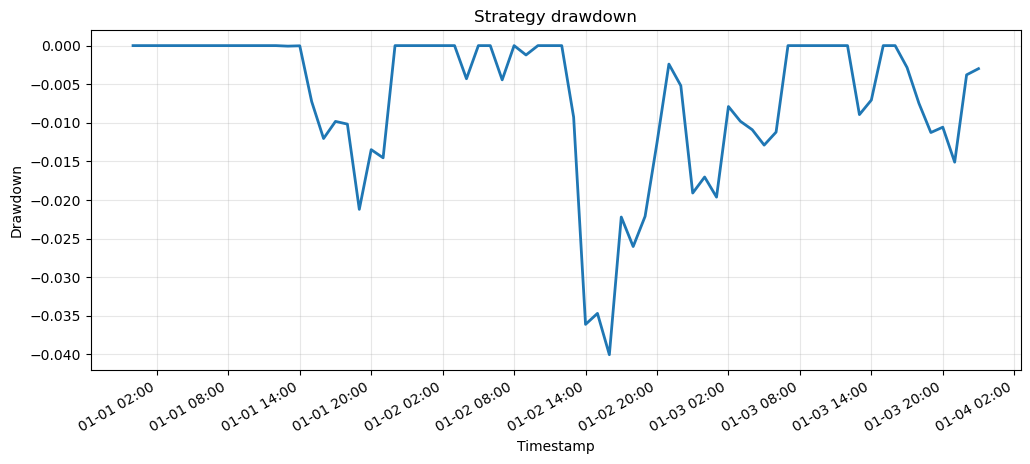

In [14]:
running_max = df["momentum_equity_curve"].cummax()
df["drawdown"] = df["momentum_equity_curve"] / running_max - 1

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["drawdown"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Momentum strategy drawdown")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Drawdown")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Momentum position


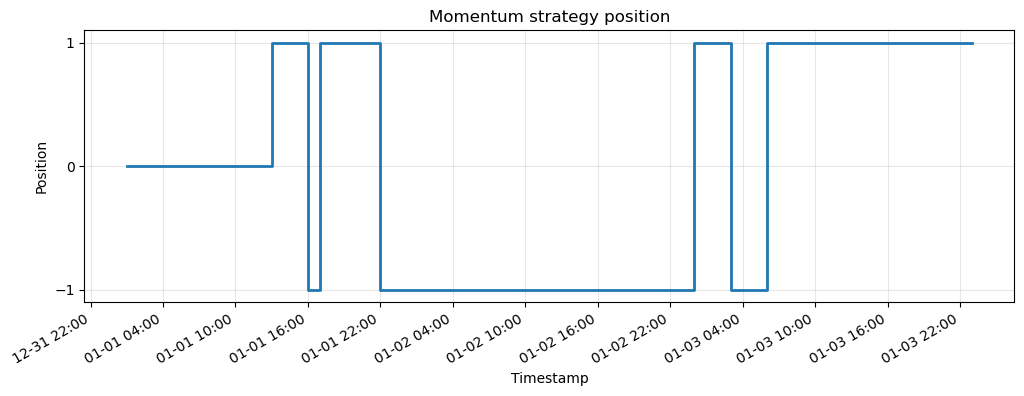

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.step(df.index, df["momentum_position"], where="post", linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Momentum strategy position")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Position")
ax.set_yticks([-1, 0, 1])
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Interpretation

This volatile sample creates a more mixed market path than the first dataset, including a decline, recovery, and several short-term reversals.

The momentum signal changes between long and short exposure as recent returns shift direction. This makes the position chart more informative than in the smoother trending sample.

The equity curve is positive on this dataset, but the drawdown chart shows that the path is not smooth. The result should be treated as an illustrative signal test, not as evidence of a robust trading strategy.

The dataset is synthetic and intentionally small, so the results are highly sample-dependent.
